In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

dataset_path = "wm-811k-augmented-and-preprocessed-dataset/archive (4)/data"

classes = os.listdir(os.path.join(dataset_path,"train"))

In [2]:
print("Dataset size per class:\n")

for cls in classes:

    folder_path = os.path.join(dataset_path, "train", cls)

    count = len(os.listdir(folder_path))

    print(f"{cls}: {count} images")

Dataset size per class:

Center: 500 images
Donut: 500 images
Edge-Loc: 500 images
Edge-Ring: 500 images
Loc: 500 images
Near-full: 500 images
none: 500 images
Random: 500 images
Scratch: 500 images


In [4]:
import torch
import torchvision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.6.0+cu124
CUDA available: True


In [10]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

# Dataset path
dataset_path = "wm-811k-augmented-and-preprocessed-dataset/archive (4)/data"

# Define transforms
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # ← ADD THIS LINE
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Load datasets
train_dataset = datasets.ImageFolder(
    root=os.path.join(dataset_path, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(dataset_path, "validation"),
    transform=train_transform
)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Print information
print(f"Train set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")

Train set size: 4500
Validation set size: 2700
Classes: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']


Image batch shape: torch.Size([32, 1, 224, 224])
Labels shape: torch.Size([32])
Unique class indices: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8])


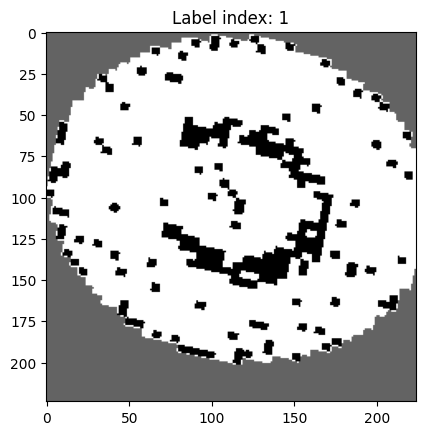

In [11]:
# Verify data loaded correctly
images, labels = next(iter(train_loader))
print(f"Image batch shape: {images.shape}")  # Should be [32, 1, 224, 224]
print(f"Labels shape: {labels.shape}")  # Should be [32]
print(f"Unique class indices: {torch.unique(labels)}")  # Should be 0-8

# Show one image to verify it's real wafer data
plt.imshow(images[0].squeeze(), cmap='gray')
plt.title(f"Label index: {labels[0]}")
plt.show()

In [12]:
from torchvision.models import resnet18
import torch.nn as nn

# Load pre-trained ResNet18
model = resnet18(pretrained=True)

# Modify first layer for grayscale (1 channel)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Modify final layer for 9 classes
num_classes = 9
model.fc = nn.Linear(512, num_classes)

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Model moved to: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters())}")

C:\Users\pragn\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\pragn\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\pragn/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [01:51<00:00, 419kB/s]


Model moved to: cuda
Model parameters: 11174857


In [13]:
import torch.optim as optim

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

print("Training setup complete")

Training setup complete


In [14]:
num_epochs = 15
best_accuracy = 0

for epoch in range(num_epochs):
    # TRAINING PHASE
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Metrics
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)
        
        if (batch_idx + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}")
    
    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total
    
    # VALIDATION PHASE
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)
    
    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total
    
    # Step scheduler
    scheduler.step()
    
    # Print results
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"  Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%")
    print(f"  Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")
    
    # Save best model
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        torch.save(model.state_dict(), 'best_wafer_model.pth')
        print(f"  ✓ Model saved! New best accuracy: {best_accuracy:.2f}%")

print(f"\nTraining complete! Best validation accuracy: {best_accuracy:.2f}%")

Epoch [1/15], Batch [10/141], Loss: 0.7806
Epoch [1/15], Batch [20/141], Loss: 1.2121
Epoch [1/15], Batch [30/141], Loss: 0.7361
Epoch [1/15], Batch [40/141], Loss: 0.7545
Epoch [1/15], Batch [50/141], Loss: 0.5161
Epoch [1/15], Batch [60/141], Loss: 0.9823
Epoch [1/15], Batch [70/141], Loss: 0.5517
Epoch [1/15], Batch [80/141], Loss: 0.6198
Epoch [1/15], Batch [90/141], Loss: 0.5997
Epoch [1/15], Batch [100/141], Loss: 0.6269
Epoch [1/15], Batch [110/141], Loss: 1.0799
Epoch [1/15], Batch [120/141], Loss: 0.7125
Epoch [1/15], Batch [130/141], Loss: 0.6925
Epoch [1/15], Batch [140/141], Loss: 0.5319

Epoch [1/15]
  Train Loss: 0.8508, Train Accuracy: 70.22%
  Val Loss: 0.6437, Val Accuracy: 77.63%
  ✓ Model saved! New best accuracy: 77.63%
Epoch [2/15], Batch [10/141], Loss: 0.3348
Epoch [2/15], Batch [20/141], Loss: 0.4554
Epoch [2/15], Batch [30/141], Loss: 0.3755
Epoch [2/15], Batch [40/141], Loss: 0.5394
Epoch [2/15], Batch [50/141], Loss: 0.7149
Epoch [2/15], Batch [60/141], Loss:

In [15]:
# Load best model
model.load_state_dict(torch.load('best_wafer_model.pth'))

# Load test set
test_dataset = datasets.ImageFolder(
    root=os.path.join(dataset_path, "test"),
    transform=train_transform
)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Evaluate
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)

test_accuracy = 100 * test_correct / test_total
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 92.06%


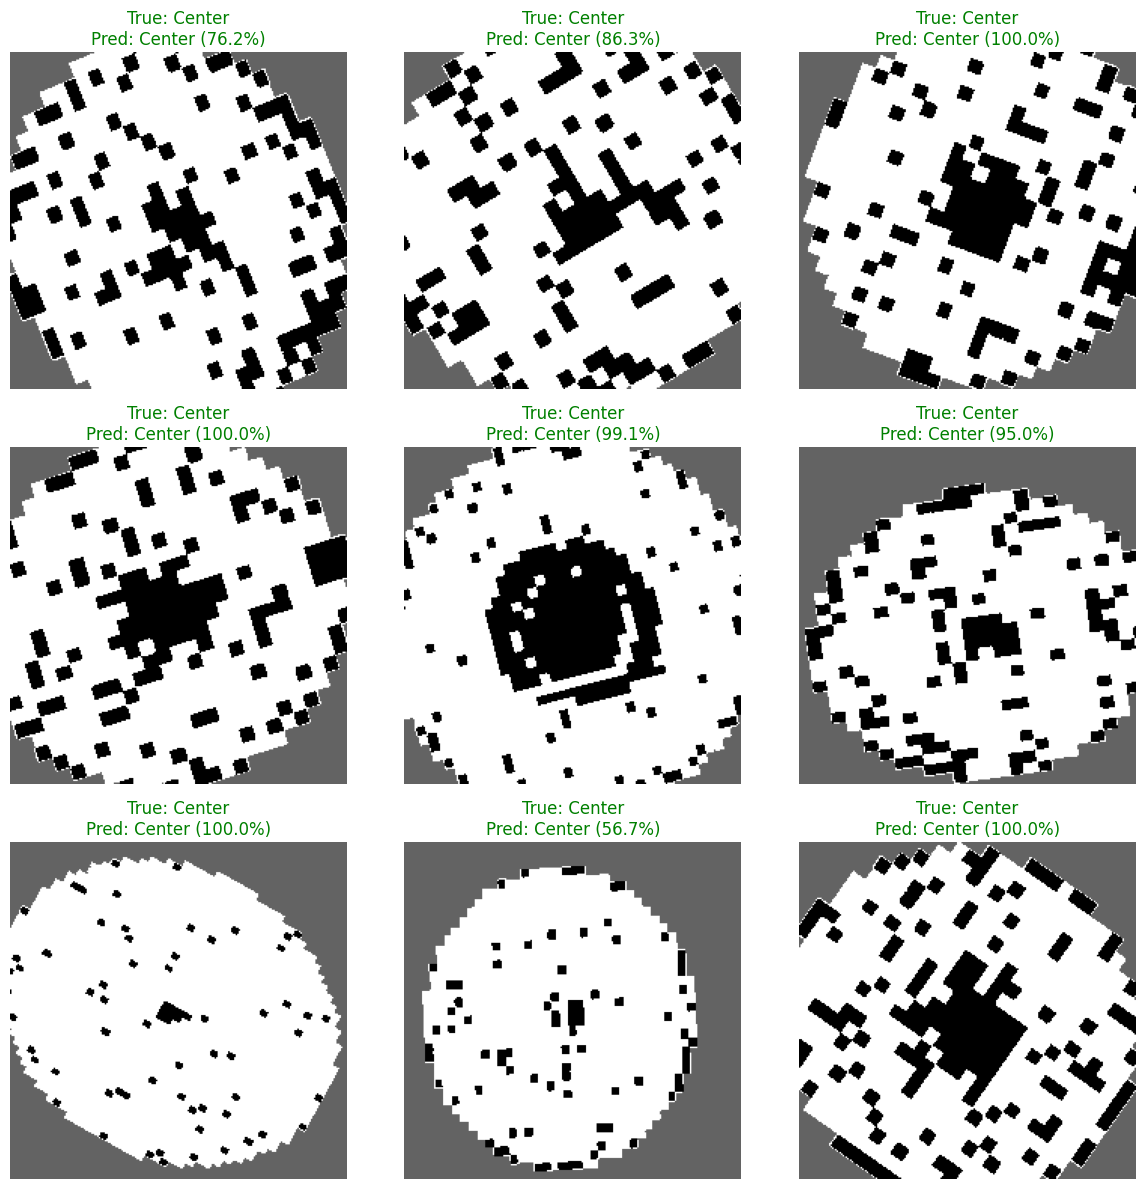

Predictions visualized!


In [16]:
# Show some predictions
model.eval()
sample_images, sample_labels = next(iter(test_loader))
sample_images = sample_images[:9].to(device)
sample_labels = sample_labels[:9].to(device)

with torch.no_grad():
    outputs = model(sample_images)
    _, predictions = torch.max(outputs, 1)
    probabilities = torch.softmax(outputs, 1)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

class_names = test_dataset.classes

for i in range(9):
    img = sample_images[i].cpu().squeeze()
    true_label = class_names[sample_labels[i]]
    pred_label = class_names[predictions[i]]
    confidence = probabilities[i][predictions[i]].item()
    
    axes[i].imshow(img, cmap='gray')
    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1%})", color=color)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('predictions.png')
plt.show()

print("Predictions visualized!")